# pyimpspec demo

[pyimpspec](https://github.com/vyrjana/pyimpspec) is a Python package for parsing, validating, analyzing, and simulating electrochemical impedance spectra. This notebook walks through its core workflow:

1. Generate/load an impedance spectrum
2. Visualize it (Nyquist & Bode plots)
3. Validate it with a Kramers-Kronig test
4. Fit an equivalent circuit model
5. Compute a distribution of relaxation times (DRT)

Run the cell below once to install the package if it isn't already available.

In [1]:
%pip install -q pyimpspec matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pyimpspec
from pyimpspec import mpl
import matplotlib.pyplot as plt

print("pyimpspec", pyimpspec.PACKAGE_VERSION)

pyimpspec 5.1.2


## 1. Get some impedance data

In a real workflow you would parse a file from your potentiostat with `pyimpspec.parse_data("path/to/file")`. Here we use pyimpspec's built-in mock data generator instead, so the notebook is fully self-contained.

`CIRCUIT_1` is a Randles-like circuit: a series resistor in series with an (Rct ∥ Cdl) pair and a Warburg-terminated branch.

In [3]:
data = pyimpspec.generate_mock_data("CIRCUIT_1", noise=5e-2, seed=42)[0]
print(data)
print(f"{len(data.get_frequencies())} points, "
      f"f = {data.get_frequencies().min():.3g} - {data.get_frequencies().max():.3g} Hz")

DataSet (Circuit 1 (noisy), 0x220089c9310)
41 points, f = 1 - 1e+04 Hz


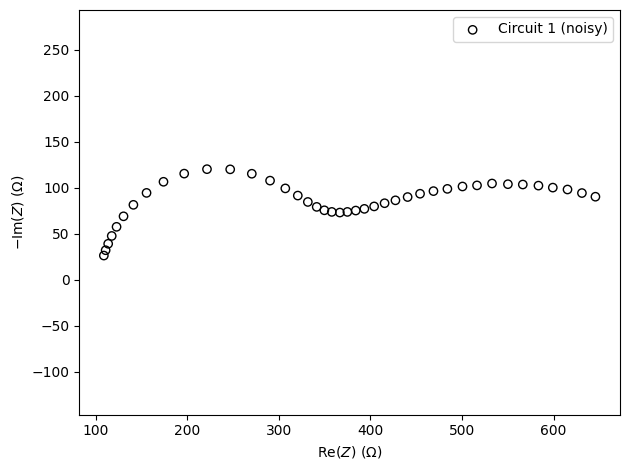

In [4]:
fig, axes = mpl.plot_nyquist(data, colors={"impedance": "black"})
fig.tight_layout()

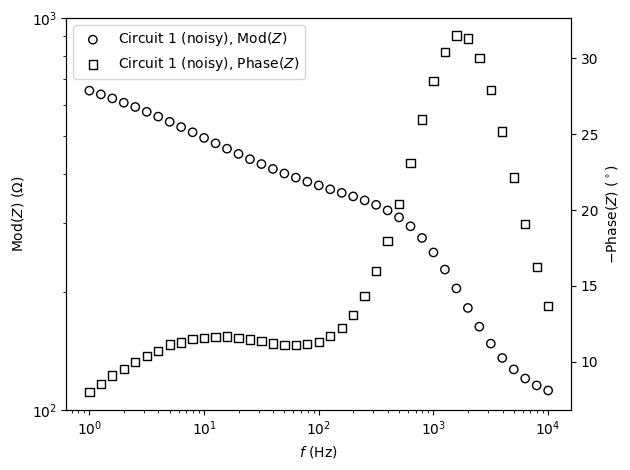

In [5]:
fig, axes = mpl.plot_bode(data, colors={"magnitude": "black", "phase": "black"})
fig.tight_layout()

## 2. Validate with a Kramers-Kronig test

Before fitting a physical model, it's good practice to check that the spectrum is linear, causal, and stable using a Kramers-Kronig test. pyimpspec automatically picks a suitable number of parallel RC elements.

Suggested number of RC elements: 13
pseudo chi-squared: 3.391e-05


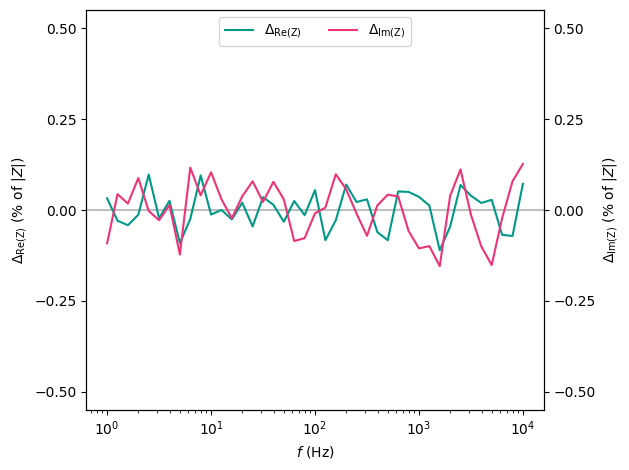

In [6]:
kk_result = pyimpspec.perform_kramers_kronig_test(data)
print(f"Suggested number of RC elements: {kk_result.num_RC}")
print(f"pseudo chi-squared: {kk_result.pseudo_chisqr:.3e}")

fig, axes = mpl.plot_residuals(kk_result)
fig.tight_layout()

Residuals scattered closely around zero with no systematic trend indicate the data is Kramers-Kronig consistent and safe to model.

## 3. Fit an equivalent circuit

Circuits are described with a compact circuit description code (CDC) string. Here we fit the same Randles-like topology used to generate the data: a series resistor, an (Rct ∥ Cdl) pair, and a Warburg element.

In [7]:
circuit = pyimpspec.parse_cdc("R(RC)(RW)")
print(circuit)

# method="leastsq" is pinned explicitly: the default "auto" selection can
# pick a method (e.g. Powell) that does not produce parameter uncertainty estimates.
fit_result = pyimpspec.fit_circuit(circuit, data, method="leastsq")

for name, parameter in fit_result.parameters.items():
    for symbol, fitted in parameter.items():
        print(f"{name:>4s} {symbol:<3s} = {fitted.value:.4g} ± {fitted.stderr:.2g} {fitted.unit}")

[R(RC)(RW)]
 R_1 R   = 100.1 ± 0.18 ohm
 R_2 R   = 197.3 ± 0.49 ohm
 C_1 C   = 8.223e-07 ± 1.7e-10 F
 R_3 R   = 495.7 ± 2.5 ohm
 W_1 Y   = 0.0003868 ± 2.4e-06 S*s^n
 W_1 n   = 0.5 ± nan 


C:\Users\fscarp\AppData\Local\Temp\ipykernel_14912\3565137237.py:2: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


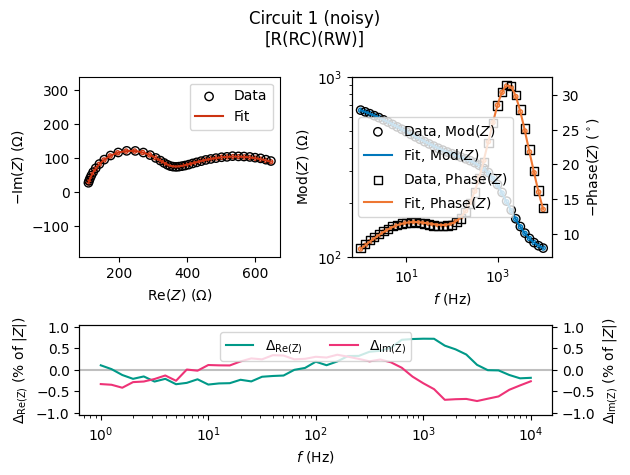

In [8]:
fig, axes = mpl.plot_fit(fit_result, data, colors={"data": "black", "fit": "red"})
fig.tight_layout()

## 4. Distribution of relaxation times (DRT)

DRT analysis is a model-free way of inspecting the time constants present in a spectrum, useful when the underlying equivalent circuit isn't known a priori.

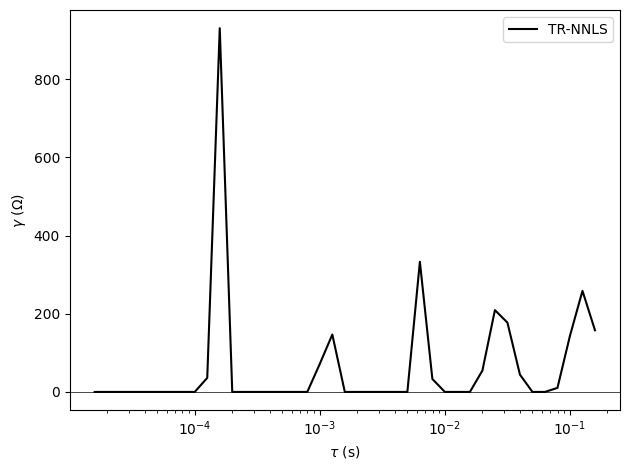

In [9]:
drt_result = pyimpspec.calculate_drt(data, method="tr-nnls")

fig, axes = mpl.plot_gamma(drt_result, colors={"gamma": "black"})
fig.tight_layout()

A single dominant peak is consistent with the single (Rct ∥ Cdl) time constant in the circuit we fitted above.

## Summary

pyimpspec covers the typical EIS analysis pipeline end to end: parsing/generating data, visualization, Kramers-Kronig validation, equivalent circuit fitting, and DRT calculation. See [its documentation](https://vyrjana.github.io/pyimpspec) for additional features such as Z-HIT, exploratory Kramers-Kronig testing, and custom circuit elements.